In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Load the expression matrix CSV with predefined clusters
data_path = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA_res_1_fx_cl_v3_FINALv2\clustered_data_cell_phenotypes.csv"
data = pd.read_csv(data_path)


In [2]:
# Ensure the last column is treated as clusters
cluster_col = data.columns[-1]  # Assuming the last column contains cluster labels
cluster_col = "Cluster"
marker_data = data.drop(
    columns=['Cell_index', 'Centroid_x', 'Centroid_y', 'Nucleus_area', 'Cell_area', 'DAPI', 'PCNA', cluster_col])


In [3]:
adata = sc.AnnData(marker_data)

C:\Users\Andre\.conda\envs\CODA_HE_nucleus_segmentation\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
adata.var_names = marker_data.columns
adata.obs[cluster_col] = data[cluster_col].astype(str)  # Store predefined clusters
marker_data.head()
print(adata.var_names)

Index(['CD4', 'IFNG', 'CD20', 'CD45RO', 'Pan-CK', 'CD141', 'Beta-actin',
       'CD14', 'SMA', 'CD11c', 'CD8', 'Vimentin', 'CD68', 'Ki67', 'EpCAM',
       'IDO1', 'MPO', 'Podoplanin', 'HLA-DR', 'CD45', 'CD31', 'CD44'],
      dtype='object')


In [5]:
# Normalize and preprocess
sc.pp.normalize_total(adata, target_sum=1e4)

In [6]:
sc.pp.log1p(adata)

In [7]:
sc.pp.scale(adata, max_value=5)

In [8]:
sc.tl.tsne(adata)

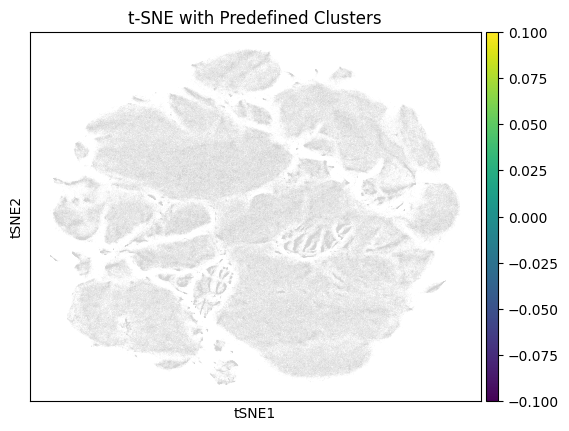

In [9]:
sc.pl.tsne(adata, color=cluster_col, title='t-SNE with Predefined Clusters')